📦 INSTALLING DEPENDENCIES
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.7/405.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━

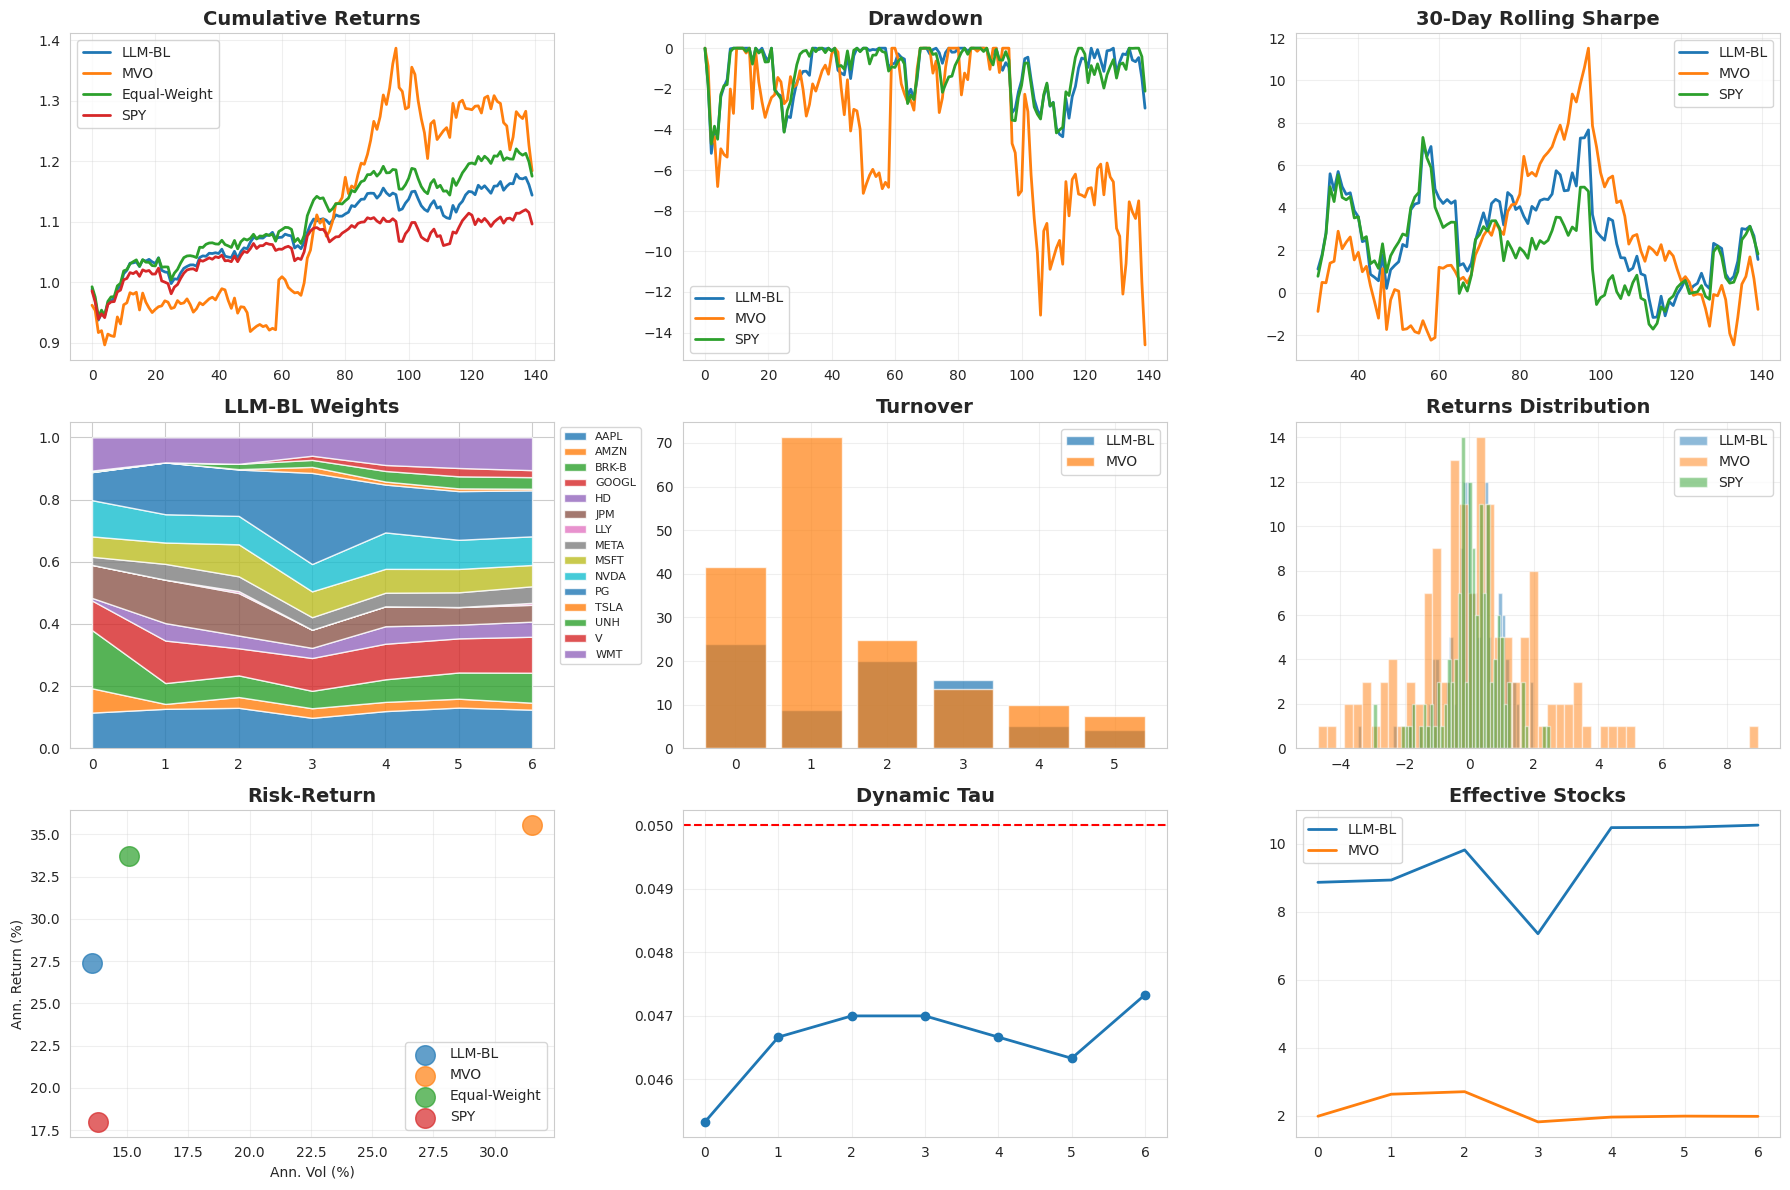


💾 EXPORTING RESULTS
✅ Saved: performance_metrics.csv
✅ Saved: weights_llm_bl.csv
✅ Saved: weights_mvo.csv

🎉 ANALYSIS COMPLETE!


In [1]:
"""
================================================================================
COMPLETE KAGGLE NOTEBOOK - ENHANCED LLM-BLACK-LITTERMAN
Self-Contained - No External Files Needed!
================================================================================

SETUP INSTRUCTIONS FOR KAGGLE:
1. Create New Notebook
2. Settings → Accelerator → GPU P100 or T4
3. If using Gemini: Add-ons → Secrets → Add "GEMINI_API_KEY"
4. Run all cells!

ESTIMATED RUNTIME:
- Mock backend: ~2 minutes (testing)
- Gemini API: ~15-20 minutes (recommended)
- Llama backend: ~25-30 minutes (includes model download)

CONFIGURATION:
- See CELL 2 to choose your LLM backend
- Default is MOCK for quick testing

================================================================================
"""

# ============================================================================
# CELL 1: INSTALL DEPENDENCIES
# ============================================================================

print("="*80)
print("📦 INSTALLING DEPENDENCIES")
print("="*80)

# Core dependencies
get_ipython().system('pip install -q yfinance cvxpy pandas numpy matplotlib seaborn tabulate')

# LLM backends (install all, use what you need)
get_ipython().system('pip install -q google-genai')  # For Gemini
get_ipython().system('pip install -q unsloth')       # For Llama

print("\n✅ Dependencies installed!")
print("="*80)

# ============================================================================
# CELL 2: IMPORTS AND CONFIGURATION CLASSES
# ============================================================================

import os
import time
import re
import json
import warnings
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass, field
from enum import Enum
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict
from tabulate import tabulate

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# ============================================================================
# CONFIGURATION CLASSES
# ============================================================================

class LLMBackend(Enum):
    """Available LLM backend options"""
    GEMINI = "gemini"
    LLAMA = "llama"
    MOCK = "mock"

@dataclass
class Config:
    """Enhanced configuration with modular LLM backend support"""
    
    # ===== DATA PARAMETERS =====
    START_DATE: str = '2024-06-01'
    END_DATE: str = '2025-02-28'
    UNIVERSE: List[str] = field(default_factory=lambda: [
        "NVDA", "MSFT", "AAPL", "AMZN", "GOOGL", "META", "TSLA",
        "BRK-B", "UNH", "LLY", "V", "WMT", "JPM", "PG", "HD"
    ])
    
    # ===== STRATEGY PARAMETERS =====
    REBALANCE_DAYS: int = 20
    RISK_AVERSION: float = 2.5
    BASE_TAU: float = 0.05
    TRANSACTION_COST: float = 0.001
    
    # ===== LLM BACKEND SELECTION =====
    LLM_BACKEND: LLMBackend = LLMBackend.MOCK  # Change this!
    
    # ===== LLM QUERY PARAMETERS =====
    N_QUERIES_PER_STOCK: int = 3
    TEMPERATURE_RANGE: List[float] = field(default_factory=lambda: [0.5, 0.7, 0.9])
    MAX_TOKENS: int = 150
    API_DELAY: float = 1.5
    
    # ===== UNCERTAINTY MODELING =====
    MIN_CONFIDENCE: float = 3.0
    CONFIDENCE_WEIGHT: float = 1.0
    DISAGREEMENT_WEIGHT: float = 0.5
    
    # ===== LLAMA-SPECIFIC SETTINGS =====
    LLAMA_MODEL: str = "unsloth/llama-3-8b-bnb-4bit"
    LLAMA_MAX_SEQ_LENGTH: int = 2048
    LLAMA_LOAD_IN_4BIT: bool = True
    LLAMA_DTYPE: Optional[str] = None
    
    # ===== GEMINI-SPECIFIC SETTINGS =====
    GEMINI_MODEL: str = "gemini-2.0-flash"
    
    # ===== FEATURES & TOGGLES =====
    USE_RELATIVE_VIEWS: bool = False
    USE_CONTEXT_ENRICHMENT: bool = True
    USE_DYNAMIC_TAU: bool = True
    ENABLE_VIEW_CORRELATION: bool = False
    
    # ===== DEBUGGING =====
    DEBUG: bool = True
    VERBOSE_LLM: bool = True
    SAVE_INTERMEDIATE: bool = True

print("✅ Configuration classes loaded")

# ============================================================================
# CELL 3: LLM RESPONSE AND BACKEND BASE CLASSES
# ============================================================================

class LLMResponse:
    """Structured LLM response container"""
    def __init__(self):
        self.return_estimate: Optional[float] = None
        self.confidence: Optional[float] = None
        self.worst_case: Optional[float] = None
        self.best_case: Optional[float] = None
        self.reasoning: Optional[str] = None
        self.raw_text: Optional[str] = None
        
    def is_valid(self) -> bool:
        return (self.return_estimate is not None and 
                self.confidence is not None)
    
    def __repr__(self):
        return (f"LLMResponse(return={self.return_estimate:.4f}, "
                f"conf={self.confidence:.1f}, range=[{self.worst_case:.4f}, {self.best_case:.4f}])")


class BaseLLMBackend(ABC):
    """Abstract base class for LLM backends"""
    
    def __init__(self, config: Config):
        self.config = config
        
    @abstractmethod
    def initialize(self) -> bool:
        pass
    
    @abstractmethod
    def query(self, prompt: str, temperature: float = 0.7) -> str:
        pass
    
    def query_structured(self, ticker: str, context: Dict, 
                        query_type: str, temperature: float = 0.7) -> LLMResponse:
        prompt = self._build_prompt(ticker, context, query_type)
        raw_response = self.query(prompt, temperature)
        parsed = self._parse_response(raw_response, query_type)
        parsed.raw_text = raw_response
        return parsed
    
    def _build_prompt(self, ticker: str, context: Dict, query_type: str) -> str:
        if query_type == "point_estimate":
            return self._build_point_estimate_prompt(ticker, context)
        elif query_type == "confidence":
            return self._build_confidence_prompt(ticker, context)
        else:
            raise ValueError(f"Unknown query type: {query_type}")
    
    def _build_point_estimate_prompt(self, ticker: str, context: Dict) -> str:
        metadata = context.get('metadata', {})
        returns_str = context.get('returns_str', '')
        market_context = context.get('market_context', {})
        
        prompt = f"""You are a quantitative financial analyst with expertise in equity markets.

STOCK: {ticker} ({metadata.get('name', ticker)})
SECTOR: {metadata.get('sector', 'Unknown')}

RECENT PERFORMANCE (Last 15 days, daily returns %):
{returns_str}

MARKET CONTEXT:
- VIX Level: {market_context.get('vix', 'N/A')}
- S&P 500 (5-day): {market_context.get('spy_5d', 'N/A')}%
- Sector Momentum: {market_context.get('sector_momentum', 'N/A')}%

TASK: Predict the average daily return for {ticker} over the next {self.config.REBALANCE_DAYS} trading days.

Think step-by-step:
1. Analyze the recent trend
2. Consider sector dynamics and market conditions
3. Factor in any upcoming catalysts or risks

Provide your answer in this EXACT format (numbers only, no extra text):
RETURN_ESTIMATE: [decimal number between -0.02 and 0.02]
REASONING: [1-2 sentences explaining your prediction]

Response:"""
        return prompt
    
    def _build_confidence_prompt(self, ticker: str, context: Dict) -> str:
        return_estimate = context.get('return_estimate', 0)
        
        prompt = f"""You predicted {return_estimate*100:.2f}% average daily return for {ticker}.

Now assess the UNCERTAINTY and CONFIDENCE of this prediction.

Consider:
- Historical volatility of {ticker}
- Upcoming events (earnings, macro data releases)
- Current market uncertainty
- Sector-specific risks

Provide your answer in this EXACT format:
CONFIDENCE: [integer from 1 to 10, where 10 = very confident, 1 = very uncertain]
WORST_CASE: [decimal, pessimistic daily return scenario]
BEST_CASE: [decimal, optimistic daily return scenario]
KEY_RISKS: [main risk factors]

Response:"""
        return prompt
    
    def _parse_response(self, raw_response: str, query_type: str) -> LLMResponse:
        response = LLMResponse()
        if not raw_response:
            return response
        
        try:
            match = re.search(r'RETURN_ESTIMATE:\s*([-+]?\d*\.?\d+)', raw_response, re.IGNORECASE)
            if match:
                response.return_estimate = float(match.group(1))
            
            match = re.search(r'CONFIDENCE:\s*(\d+)', raw_response, re.IGNORECASE)
            if match:
                response.confidence = float(match.group(1))
            
            match = re.search(r'WORST[_\s]CASE:\s*([-+]?\d*\.?\d+)', raw_response, re.IGNORECASE)
            if match:
                response.worst_case = float(match.group(1))
            
            match = re.search(r'BEST[_\s]CASE:\s*([-+]?\d*\.?\d+)', raw_response, re.IGNORECASE)
            if match:
                response.best_case = float(match.group(1))
            
            match = re.search(r'REASONING:\s*(.+?)(?=\n[A-Z_]+:|$)', raw_response, re.IGNORECASE | re.DOTALL)
            if match:
                response.reasoning = match.group(1).strip()
                
        except Exception as e:
            if self.config.DEBUG:
                print(f"    ! Parsing error: {e}")
        
        return response

print("✅ LLM base classes loaded")

# ============================================================================
# CELL 4: LLM BACKEND IMPLEMENTATIONS
# ============================================================================

class GeminiBackend(BaseLLMBackend):
    """Google Gemini API backend"""
    
    def __init__(self, config: Config):
        super().__init__(config)
        self.client = None
        
    def initialize(self) -> bool:
        try:
            from google import genai
            from google.genai import types
            
            api_key = self._get_api_key()
            if not api_key:
                print("❌ GEMINI_API_KEY not found!")
                return False
            
            self.client = genai.Client(api_key=api_key)
            self.types = types
            print("✅ Gemini API initialized")
            return True
            
        except ImportError:
            print("❌ google-genai not installed")
            return False
    
    def _get_api_key(self) -> Optional[str]:
        try:
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret("GEMINI_API_KEY")
        except:
            return os.environ.get("GEMINI_API_KEY")
    
    def query(self, prompt: str, temperature: float = 0.7) -> str:
        try:
            response = self.client.models.generate_content(
                model=self.config.GEMINI_MODEL,
                contents=[self.types.Content(
                    role="user",
                    parts=[self.types.Part.from_text(text=prompt)]
                )],
                config=self.types.GenerateContentConfig(
                    temperature=temperature,
                    max_output_tokens=self.config.MAX_TOKENS
                )
            )
            time.sleep(self.config.API_DELAY)
            return response.text if response else None
        except Exception as e:
            if self.config.DEBUG:
                print(f"    ! Gemini API error: {str(e)[:50]}...")
            return None


class LlamaBackend(BaseLLMBackend):
    """Local Llama model via Unsloth"""
    
    def __init__(self, config: Config):
        super().__init__(config)
        self.model = None
        self.tokenizer = None
        
    def initialize(self) -> bool:
        try:
            from unsloth import FastLanguageModel
            import torch
            
            print(f"🦙 Loading Llama model: {self.config.LLAMA_MODEL}")
            print("   (This may take 2-3 minutes on first load...)")
            
            self.model, self.tokenizer = FastLanguageModel.from_pretrained(
                model_name=self.config.LLAMA_MODEL,
                max_seq_length=self.config.LLAMA_MAX_SEQ_LENGTH,
                dtype=self.config.LLAMA_DTYPE,
                load_in_4bit=self.config.LLAMA_LOAD_IN_4BIT,
            )
            
            FastLanguageModel.for_inference(self.model)
            print("✅ Llama model loaded successfully")
            return True
            
        except ImportError:
            print("❌ Unsloth not installed")
            return False
        except Exception as e:
            print(f"❌ Failed to load Llama: {e}")
            return False
    
    def query(self, prompt: str, temperature: float = 0.7) -> str:
        try:
            inputs = self.tokenizer([prompt], return_tensors="pt").to(
                "cuda" if self.model.device.type == "cuda" else "cpu"
            )
            
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=self.config.MAX_TOKENS,
                temperature=temperature,
                use_cache=True,
                pad_token_id=self.tokenizer.eos_token_id
            )
            
            response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
            response = response[len(prompt):].strip()
            return response
            
        except Exception as e:
            if self.config.DEBUG:
                print(f"    ! Llama inference error: {str(e)[:50]}...")
            return None


class MockLLMBackend(BaseLLMBackend):
    """Mock LLM for testing without API/GPU"""
    
    def __init__(self, config: Config):
        super().__init__(config)
        self.call_count = 0
        
    def initialize(self) -> bool:
        print("🔧 Mock LLM backend initialized (for testing)")
        return True
    
    def query(self, prompt: str, temperature: float = 0.7) -> str:
        self.call_count += 1
        
        if "RETURN_ESTIMATE" in prompt:
            base_return = np.random.normal(0.001, 0.003)
            return f"""RETURN_ESTIMATE: {base_return:.6f}
REASONING: Based on recent momentum and sector dynamics, expecting moderate {'positive' if base_return > 0 else 'negative'} movement."""
        
        elif "CONFIDENCE" in prompt:
            confidence = np.random.randint(5, 9)
            base = float(re.search(r'([-+]?\d*\.?\d+)%', prompt).group(1)) / 100
            return f"""CONFIDENCE: {confidence}
WORST_CASE: {base - 0.005:.6f}
BEST_CASE: {base + 0.005:.6f}
KEY_RISKS: Market volatility, sector rotation, macro uncertainty"""
        
        return "Error: Unknown query type"


class LLMFactory:
    """Factory to create appropriate LLM backend"""
    
    @staticmethod
    def create(config: Config) -> BaseLLMBackend:
        backend_map = {
            LLMBackend.GEMINI: GeminiBackend,
            LLMBackend.LLAMA: LlamaBackend,
            LLMBackend.MOCK: MockLLMBackend,
        }
        
        backend_class = backend_map.get(config.LLM_BACKEND)
        backend = backend_class(config)
        
        if not backend.initialize():
            print(f"\n⚠️  Failed to initialize {config.LLM_BACKEND.value} backend")
            print("💡 Falling back to Mock backend")
            config.LLM_BACKEND = LLMBackend.MOCK
            backend = MockLLMBackend(config)
            backend.initialize()
        
        return backend

print("✅ LLM backends loaded")

# ============================================================================
# CELL 5: MARKET CONTEXT BUILDER
# ============================================================================

class MarketContextBuilder:
    """Build rich market context for LLM prompts"""
    
    def __init__(self, config: Config):
        self.config = config
        self.vix_data = None
        self.spy_data = None
        self.sector_etfs = {
            'Technology': 'XLK',
            'Financials': 'XLF',
            'Healthcare': 'XLV',
            'Energy': 'XLE',
            'Consumer': 'XLY',
        }
        self.sector_data = {}
        
    def initialize(self, start_date: str, end_date: str):
        print("📊 Fetching market context data...")
        
        try:
            self.vix_data = yf.download('^VIX', start=start_date, end=end_date, 
                                       progress=False)['Close']
            print("  ✓ VIX data loaded")
        except:
            print("  ⚠ VIX data unavailable")
            
        try:
            self.spy_data = yf.download('SPY', start=start_date, end=end_date, 
                                       progress=False)['Close']
            print("  ✓ SPY data loaded")
        except:
            print("  ⚠ SPY data unavailable")
            
        for sector, etf in self.sector_etfs.items():
            try:
                self.sector_data[sector] = yf.download(etf, start=start_date, 
                                                       end=end_date, progress=False)['Close']
                print(f"  ✓ {sector} sector data loaded")
            except:
                pass
    
    def get_context(self, current_date, ticker_sector: str = None) -> Dict:
        context = {}
        
        try:
            if self.vix_data is not None and current_date in self.vix_data.index:
                vix_val = self.vix_data.loc[current_date]
                context['vix'] = f"{vix_val:.1f}"
                context['vix_regime'] = self._classify_vix(vix_val)
            else:
                context['vix'] = 'N/A'
            
            if self.spy_data is not None and current_date in self.spy_data.index:
                spy_5d = self.spy_data.loc[:current_date].pct_change(5).iloc[-1] * 100
                context['spy_5d'] = f"{spy_5d:.2f}"
            else:
                context['spy_5d'] = 'N/A'
            
            if ticker_sector and ticker_sector in self.sector_data:
                sector_series = self.sector_data[ticker_sector]
                if current_date in sector_series.index:
                    sect_mom = sector_series.loc[:current_date].pct_change(10).iloc[-1] * 100
                    context['sector_momentum'] = f"{sect_mom:.2f}"
                else:
                    context['sector_momentum'] = 'N/A'
            else:
                context['sector_momentum'] = 'N/A'
                
        except Exception as e:
            if self.config.DEBUG:
                print(f"    Context warning: {e}")
        
        return context
    
    @staticmethod
    def _classify_vix(vix_val: float) -> str:
        if vix_val < 15:
            return "Low Volatility"
        elif vix_val < 25:
            return "Normal Volatility"
        else:
            return "High Volatility"

print("✅ Market context builder loaded")

# ============================================================================
# CELL 6: ENHANCED VIEW GENERATOR
# ============================================================================

class EnhancedViewGenerator:
    """Generate LLM views with uncertainty quantification"""
    
    def __init__(self, llm_backend: BaseLLMBackend, 
                 market_context: MarketContextBuilder,
                 config: Config):
        self.llm = llm_backend
        self.market_context = market_context
        self.config = config
        self.stats = {
            'total_queries': 0,
            'successful_queries': 0,
            'failed_queries': 0,
            'by_ticker': defaultdict(lambda: {'success': 0, 'fail': 0}),
            'disagreement_scores': [],
            'confidence_scores': [],
        }
    
    def generate_views(self, tickers: List[str], prices: pd.DataFrame,
                      metadata: Dict, current_date) -> Tuple:
        print(f"  🤖 Generating LLM views for {len(tickers)} stocks...")
        
        view_returns = []
        view_uncertainties = []
        confidences = []
        valid_indices = []
        
        market_ctx = self.market_context.get_context(current_date)
        
        for idx, ticker in enumerate(tickers):
            if self.config.DEBUG:
                print(f"    Querying {ticker}...")
            
            stock_context = self._build_stock_context(
                ticker, prices, metadata[ticker], current_date, market_ctx
            )
            
            view = self._generate_single_view(ticker, stock_context)
            
            if view is not None:
                mu, omega, conf = view
                view_returns.append(mu)
                view_uncertainties.append(omega)
                confidences.append(conf)
                valid_indices.append(idx)
                
                if self.config.DEBUG:
                    print(f"      ✓ μ={mu*100:.3f}%, σ²={omega:.8f}, conf={conf:.1f}/10")
            else:
                if self.config.DEBUG:
                    print(f"      ✗ No valid view")
                self.stats['failed_queries'] += 1
        
        print(f"  📊 Generated {len(view_returns)}/{len(tickers)} valid views")
        
        return (np.array(view_returns), np.array(view_uncertainties), 
                np.array(confidences), valid_indices)
    
    def _build_stock_context(self, ticker: str, prices: pd.DataFrame,
                            metadata: Dict, current_date, market_ctx: Dict) -> Dict:
        hist_prices = prices.loc[:current_date, ticker].tail(15)
        returns = hist_prices.pct_change().dropna()
        returns_pct = returns * 100
        returns_str = returns_pct.to_string(header=False, float_format="{:.2f}%".format)
        
        context = {
            'metadata': metadata,
            'returns_str': returns_str,
            'market_context': market_ctx,
            'hist_volatility': returns.std(),
            'recent_return': returns.iloc[-1] if len(returns) > 0 else 0,
        }
        return context
    
    def _generate_single_view(self, ticker: str, context: Dict) -> Optional[Tuple]:
        estimates = []
        for i, temp in enumerate(self.config.TEMPERATURE_RANGE):
            self.stats['total_queries'] += 1
            
            try:
                response = self.llm.query_structured(
                    ticker, context, 'point_estimate', temperature=temp
                )
                
                if response.return_estimate is not None:
                    if abs(response.return_estimate) < 0.05:
                        estimates.append(response.return_estimate)
                        self.stats['successful_queries'] += 1
                        
                        if self.config.VERBOSE_LLM and i == 0:
                            print(f"        LLM: \"{response.reasoning[:60] if response.reasoning else 'N/A'}...\"")
                            
            except Exception as e:
                if self.config.DEBUG:
                    print(f"        ! Query error: {str(e)[:40]}")
                continue
        
        if len(estimates) == 0:
            return None
        
        mu_llm = np.mean(estimates)
        disagreement = np.std(estimates) if len(estimates) > 1 else 0
        self.stats['disagreement_scores'].append(disagreement)
        
        confidence = 5.0
        worst_case = mu_llm - 0.01
        best_case = mu_llm + 0.01
        
        try:
            context['return_estimate'] = mu_llm
            conf_response = self.llm.query_structured(
                ticker, context, 'confidence', temperature=0.7
            )
            
            if conf_response.confidence is not None:
                confidence = np.clip(conf_response.confidence, 1, 10)
                self.stats['confidence_scores'].append(confidence)
                
            if conf_response.worst_case is not None:
                worst_case = conf_response.worst_case
            if conf_response.best_case is not None:
                best_case = conf_response.best_case
                
        except Exception as e:
            if self.config.DEBUG:
                print(f"        ! Confidence query failed: {str(e)[:40]}")
        
        omega = self._construct_uncertainty(
            mu_llm, confidence, worst_case, best_case,
            disagreement, context['hist_volatility']
        )
        
        if confidence < self.config.MIN_CONFIDENCE:
            if self.config.DEBUG:
                print(f"        ⚠ Confidence {confidence:.1f} below threshold")
            return None
        
        self.stats['by_ticker'][ticker]['success'] += 1
        return (mu_llm, omega, confidence)
    
    def _construct_uncertainty(self, mu: float, confidence: float,
                              worst: float, best: float, 
                              disagreement: float, hist_vol: float) -> float:
        base_uncertainty = hist_vol ** 2
        conf_multiplier = (11 - confidence) / 10
        conf_uncertainty = base_uncertainty * conf_multiplier * self.config.CONFIDENCE_WEIGHT
        range_uncertainty = ((best - worst) / 4) ** 2
        disagreement_uncertainty = (disagreement ** 2) * self.config.DISAGREEMENT_WEIGHT
        omega_ii = conf_uncertainty + range_uncertainty + disagreement_uncertainty
        min_omega = (hist_vol * 0.5) ** 2
        omega_ii = max(omega_ii, min_omega)
        return omega_ii
    
    def print_statistics(self):
        print("\n" + "="*80)
        print("LLM QUERY STATISTICS")
        print("="*80)
        
        print(f"\nTotal Queries: {self.stats['total_queries']}")
        print(f"Successful: {self.stats['successful_queries']} "
              f"({self.stats['successful_queries']/max(1,self.stats['total_queries'])*100:.1f}%)")
        print(f"Failed: {self.stats['failed_queries']}")
        
        if self.stats['disagreement_scores']:
            print(f"\nMulti-Query Disagreement:")
            print(f"  Mean: {np.mean(self.stats['disagreement_scores'])*100:.4f}%")
            print(f"  Max:  {np.max(self.stats['disagreement_scores'])*100:.4f}%")
        
        if self.stats['confidence_scores']:
            print(f"\nLLM Confidence Scores:")
            print(f"  Mean: {np.mean(self.stats['confidence_scores']):.2f}/10")
            print(f"  Range: [{np.min(self.stats['confidence_scores']):.1f}, "
                  f"{np.max(self.stats['confidence_scores']):.1f}]")

print("✅ View generator loaded")

# ============================================================================
# CELL 7: DYNAMIC TAU AND BLACK-LITTERMAN
# ============================================================================

class DynamicTauCalculator:
    """Calculate adaptive tau"""
    
    def __init__(self, base_tau: float = 0.05):
        self.base_tau = base_tau
    
    def calculate(self, confidences: np.ndarray, vix_level: Optional[float] = None) -> float:
        avg_confidence = np.mean(confidences) / 10 if len(confidences) > 0 else 0.5
        conf_multiplier = 0.5 + avg_confidence
        
        if vix_level is not None:
            if vix_level < 15:
                vix_multiplier = 1.2
            elif vix_level < 25:
                vix_multiplier = 1.0
            else:
                vix_multiplier = 0.7
        else:
            vix_multiplier = 1.0
        
        tau = self.base_tau * conf_multiplier * vix_multiplier
        tau = np.clip(tau, 0.02, 0.15)
        return tau


def calculate_bl_posterior(equilibrium_returns: np.ndarray,
                           cov_matrix: np.ndarray,
                           P: np.ndarray,
                           Q: np.ndarray,
                           Omega: np.ndarray,
                           tau: float) -> Tuple[np.ndarray, np.ndarray]:
    try:
        tau_cov = tau * cov_matrix
        tau_cov_inv = np.linalg.inv(tau_cov)
        omega_inv = np.linalg.inv(Omega)
        
        posterior_precision = tau_cov_inv + P.T @ omega_inv @ P
        posterior_cov_tau = np.linalg.inv(posterior_precision)
        
        prior_term = tau_cov_inv @ equilibrium_returns
        view_term = P.T @ omega_inv @ Q
        posterior_returns = posterior_cov_tau @ (prior_term + view_term)
        posterior_cov = posterior_cov_tau + cov_matrix
        
        return posterior_returns, posterior_cov
        
    except np.linalg.LinAlgError as e:
        print(f"    ! Matrix inversion error: {e}")
        return equilibrium_returns, cov_matrix


def optimize_portfolio(expected_returns: np.ndarray,
                      cov_matrix: np.ndarray,
                      risk_aversion: float) -> np.ndarray:
    n = len(expected_returns)
    w = cp.Variable(n)
    
    cov_matrix_psd = cov_matrix + np.eye(n) * 1e-6
    risk = cp.quad_form(w, cp.psd_wrap(cov_matrix_psd))
    ret = expected_returns @ w
    objective = cp.Minimize(risk_aversion * risk - ret)
    
    constraints = [cp.sum(w) == 1, w >= 0]
    
    try:
        problem = cp.Problem(objective, constraints)
        problem.solve()
        
        if w.value is None:
            return np.ones(n) / n
        
        weights = np.array(w.value)
        weights = np.maximum(weights, 0)
        weights = weights / np.sum(weights)
        return weights
        
    except Exception as e:
        print(f"    ! Optimization error: {e}")
        return np.ones(n) / n

print("✅ Black-Litterman functions loaded")

# ============================================================================
# CELL 8: UTILITY FUNCTIONS
# ============================================================================

def download_prices(tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
    print(f"📥 Downloading {len(tickers)} stocks...")
    df = yf.download(tickers, start=start_date, end=end_date, 
                     interval="1d", progress=False, auto_adjust=True)
    
    if len(tickers) == 1:
        if 'Close' in df.columns:
            prices = df[['Close']].rename(columns={'Close': tickers[0]})
        else:
            prices = df.iloc[:, [0]].rename(columns={df.columns[0]: tickers[0]})
    else:
        if isinstance(df.columns, pd.MultiIndex):
            prices = df['Close']
        else:
            prices = df
    
    prices = prices.dropna(axis=1, thresh=len(prices)*0.9).ffill().dropna()
    print(f"✅ Downloaded {len(prices.columns)} stocks, {len(prices)} days")
    return prices


def get_metadata(tickers: List[str]) -> Dict:
    metadata = {}
    print("📋 Fetching metadata...")
    for ticker in tickers:
        try:
            info = yf.Ticker(ticker).info
            metadata[ticker] = {
                'name': info.get('longName', ticker),
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown')
            }
        except:
            metadata[ticker] = {
                'name': ticker,
                'sector': 'Unknown',
                'industry': 'Unknown'
            }
    return metadata


def get_market_caps(tickers: List[str]) -> pd.Series:
    caps = {}
    for ticker in tickers:
        try:
            info = yf.Ticker(ticker).fast_info
            caps[ticker] = info.market_cap
        except:
            caps[ticker] = 1e9
    return pd.Series(caps)


def calculate_turnover(old_weights: np.ndarray, new_weights: np.ndarray) -> float:
    return np.sum(np.abs(new_weights - old_weights)) / 2

print("✅ Utility functions loaded")

# ============================================================================
# CELL 9: MAIN BACKTEST FUNCTION
# ============================================================================

def run_enhanced_backtest(config: Config):
    print("\n" + "="*80)
    print("ENHANCED LLM-BLACK-LITTERMAN BACKTEST")
    print("="*80)
    print(f"\n📍 Backend: {config.LLM_BACKEND.value.upper()}")
    print(f"📅 Period: {config.START_DATE} to {config.END_DATE}")
    print(f"🔄 Rebalance: Every {config.REBALANCE_DAYS} days")
    print(f"🎯 Stocks: {len(config.UNIVERSE)}")
    
    llm = LLMFactory.create(config)
    market_context = MarketContextBuilder(config)
    view_generator = EnhancedViewGenerator(llm, market_context, config)
    tau_calculator = DynamicTauCalculator(config.BASE_TAU)
    
    prices = download_prices(config.UNIVERSE, config.START_DATE, config.END_DATE)
    metadata = get_metadata(config.UNIVERSE)
    tickers = list(prices.columns)
    
    market_context.initialize(config.START_DATE, config.END_DATE)
    
    spy_prices = yf.download('SPY', start=config.START_DATE, end=config.END_DATE, 
                            progress=False, auto_adjust=True)
    # Ensure it's a Series
    if isinstance(spy_prices, pd.DataFrame):
        if 'Close' in spy_prices.columns:
            spy_prices = spy_prices['Close']
        else:
            spy_prices = spy_prices.iloc[:, 0]
    
    rebalance_dates = prices.index[::config.REBALANCE_DAYS]
    
    results = {
        'LLM-BL': {'weights': [], 'returns': [], 'dates': [], 'turnover': [], 'tau_history': []},
        'MVO': {'weights': [], 'returns': [], 'dates': [], 'turnover': []},
        'Equal-Weight': {'weights': [], 'returns': [], 'dates': []},
        'SPY': {'returns': [], 'dates': []}
    }
    
    print(f"\n🚀 Running backtest: {len(rebalance_dates)-1} periods")
    print("="*80)
    
    for i in range(len(rebalance_dates) - 1):
        curr_date = rebalance_dates[i]
        next_date = rebalance_dates[i + 1]
        
        print(f"\n📅 Period {i+1}/{len(rebalance_dates)-1}: {curr_date.date()} → {next_date.date()}")
        print("-"*80)
        
        hist_prices = prices.loc[:curr_date]
        if len(hist_prices) < 30:
            continue
        
        returns = hist_prices.pct_change().dropna()
        cov_matrix = returns.cov().values
        
        caps = get_market_caps(tickers)
        mkt_weights = caps.values / caps.sum()
        pi_prior = config.RISK_AVERSION * cov_matrix @ mkt_weights
        
        view_rets, view_uncert, confidences, valid_idx = view_generator.generate_views(
            tickers, prices, metadata, curr_date
        )
        
        if len(view_rets) > 0:
            P = np.zeros((len(view_rets), len(tickers)))
            for row, col in enumerate(valid_idx):
                P[row, col] = 1
            
            Omega = np.diag(view_uncert)
            
            vix_val = None
            try:
                ctx = market_context.get_context(curr_date)
                if ctx['vix'] != 'N/A':
                    vix_val = float(ctx['vix'])
            except:
                pass
            
            tau = tau_calculator.calculate(confidences, vix_val)
            results['LLM-BL']['tau_history'].append(tau)
            
            print(f"  📊 τ={tau:.4f} (base={config.BASE_TAU}, avg_conf={np.mean(confidences):.1f}/10)")
            
            post_ret, post_cov = calculate_bl_posterior(
                pi_prior, cov_matrix, P, view_rets, Omega, tau
            )
            
            print("  ⚙️  Optimizing LLM-BL portfolio...")
            bl_weights = optimize_portfolio(post_ret, post_cov, config.RISK_AVERSION)
        else:
            bl_weights = mkt_weights
        
        print("  ⚙️  Optimizing MVO baseline...")
        mvo_weights = optimize_portfolio(returns.mean().values, cov_matrix, config.RISK_AVERSION)
        ew_weights = np.ones(len(tickers)) / len(tickers)
        
        if len(results['LLM-BL']['weights']) > 0:
            bl_turn = calculate_turnover(results['LLM-BL']['weights'][-1], bl_weights)
            mvo_turn = calculate_turnover(results['MVO']['weights'][-1], mvo_weights)
            results['LLM-BL']['turnover'].append(bl_turn)
            results['MVO']['turnover'].append(mvo_turn)
            print(f"  🔄 Turnover: LLM-BL={bl_turn:.1%}, MVO={mvo_turn:.1%}")
        
        results['LLM-BL']['weights'].append(bl_weights)
        results['MVO']['weights'].append(mvo_weights)
        results['Equal-Weight']['weights'].append(ew_weights)
        
        for strat in ['LLM-BL', 'MVO', 'Equal-Weight']:
            results[strat]['dates'].append(curr_date)
        
        bl_top = np.argsort(bl_weights)[::-1][:3]
        mvo_top = np.argsort(mvo_weights)[::-1][:3]
        print(f"\n  📊 Top 3 Holdings:")
        print(f"     LLM-BL: {', '.join([f'{tickers[i]}({bl_weights[i]:.1%})' for i in bl_top])}")
        print(f"     MVO:    {', '.join([f'{tickers[i]}({mvo_weights[i]:.1%})' for i in mvo_top])}")
        
        period_prices = prices.loc[curr_date:next_date]
        period_rets = period_prices.pct_change().dropna()
        
        if not period_rets.empty:
            bl_rets = (period_rets @ bl_weights).tolist()
            mvo_rets = (period_rets @ mvo_weights).tolist()
            ew_rets = (period_rets @ ew_weights).tolist()
            
            if len(results['LLM-BL']['turnover']) > 0:
                bl_rets[0] -= results['LLM-BL']['turnover'][-1] * config.TRANSACTION_COST
                mvo_rets[0] -= results['MVO']['turnover'][-1] * config.TRANSACTION_COST
            
            results['LLM-BL']['returns'].extend(bl_rets)
            results['MVO']['returns'].extend(mvo_rets)
            results['Equal-Weight']['returns'].extend(ew_rets)
        
        spy_period = spy_prices.loc[curr_date:next_date]
        spy_rets = spy_period.pct_change().dropna()
        if not spy_rets.empty:
            # Handle both Series and DataFrame
            if isinstance(spy_rets, pd.DataFrame):
                spy_rets_list = spy_rets.iloc[:, 0].tolist()
            else:
                spy_rets_list = spy_rets.tolist()
            results['SPY']['returns'].extend(spy_rets_list)
    
    view_generator.print_statistics()
    
    print("\n" + "="*80)
    print("✅ BACKTEST COMPLETE!")
    print("="*80)
    
    return results, prices, tickers

print("✅ All functions loaded and ready!")

# ============================================================================
# CELL 10: CONFIGURE AND RUN BACKTEST
# ============================================================================

print("\n" + "="*80)
print("⚙️  CONFIGURATION")
print("="*80)

# Create config
config = Config()

# ===== CHOOSE YOUR LLM BACKEND =====
# Uncomment ONE of these:

# OPTION 1: Mock LLM (Fast testing, no API/GPU needed) - DEFAULT
# config.LLM_BACKEND = LLMBackend.MOCK
# print("🔧 Using MOCK backend (testing mode)")

# OPTION 2: Gemini API (Recommended for real results)
config.LLM_BACKEND = LLMBackend.GEMINI
config.GEMINI_MODEL = "gemini-2.0-flash"
print("🌟 Using GEMINI API - Make sure GEMINI_API_KEY is in Kaggle Secrets!")

# OPTION 3: Local Llama (No API costs, requires GPU)
# config.LLM_BACKEND = LLMBackend.LLAMA
# config.LLAMA_MODEL = "unsloth/llama-3-8b-bnb-4bit"
# print("🦙 Using LOCAL LLAMA - First run will download ~4GB model")

# ===== ADJUST PARAMETERS IF DESIRED =====
config.REBALANCE_DAYS = 20
config.USE_DYNAMIC_TAU = True
config.MIN_CONFIDENCE = 3.0

print(f"\n📋 Configuration:")
print(f"   Backend: {config.LLM_BACKEND.value}")
print(f"   Period: {config.START_DATE} to {config.END_DATE}")
print(f"   Rebalance: Every {config.REBALANCE_DAYS} days")
print(f"   Stocks: {len(config.UNIVERSE)}")

# RUN BACKTEST
print("\n" + "="*80)
print("🚀 STARTING BACKTEST")
print("="*80)

results, prices, tickers = run_enhanced_backtest(config)

print("\n✅ Backtest completed successfully!")

# ============================================================================
# CELL 11: CALCULATE AND DISPLAY METRICS
# ============================================================================

print("\n" + "="*80)
print("📊 PERFORMANCE ANALYSIS")
print("="*80)

def calculate_metrics(returns):
    if len(returns) == 0:
        return {}
    
    returns = np.array(returns)
    cum_ret = np.prod(1 + returns) - 1
    ann_ret = (1 + cum_ret) ** (252 / len(returns)) - 1
    ann_vol = np.std(returns) * np.sqrt(252)
    sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(252) if np.std(returns) > 0 else 0
    
    cum_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    max_dd = np.min(drawdown)
    
    return {
        'Cumulative Return': cum_ret,
        'Annualized Return': ann_ret,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Total Days': len(returns)
    }

metrics = {}
for strat in ['LLM-BL', 'MVO', 'Equal-Weight', 'SPY']:
    if len(results[strat]['returns']) > 0:
        metrics[strat] = calculate_metrics(results[strat]['returns'])

if metrics:
    print("\n" + "="*80)
    print("STRATEGY COMPARISON")
    print("="*80 + "\n")
    
    headers = ['Strategy', 'Cum. Return', 'Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD']
    rows = []
    
    for strat in ['LLM-BL', 'MVO', 'Equal-Weight', 'SPY']:
        if strat in metrics:
            m = metrics[strat]
            rows.append([
                strat,
                f"{m['Cumulative Return']:.2%}",
                f"{m['Annualized Return']:.2%}",
                f"{m['Annualized Volatility']:.2%}",
                f"{m['Sharpe Ratio']:.3f}",
                f"{m['Max Drawdown']:.2%}"
            ])
    
    print(tabulate(rows, headers=headers, tablefmt='grid'))

# Turnover
if len(results['LLM-BL']['turnover']) > 0:
    print("\n" + "="*80)
    print("TURNOVER ANALYSIS")
    print("="*80 + "\n")
    
    for strat in ['LLM-BL', 'MVO']:
        if len(results[strat]['turnover']) > 0:
            turn = results[strat]['turnover']
            print(f"{strat}:")
            print(f"  Average: {np.mean(turn):.2%}")
            print(f"  Median:  {np.median(turn):.2%}")
            print(f"  Max:     {np.max(turn):.2%}")

# Concentration
if len(results['LLM-BL']['weights']) > 0:
    print("\n" + "="*80)
    print("PORTFOLIO CONCENTRATION")
    print("="*80 + "\n")
    
    for strat in ['LLM-BL', 'MVO', 'Equal-Weight']:
        if len(results[strat]['weights']) > 0:
            weights = results[strat]['weights']
            hhi = [np.sum(w**2) for w in weights]
            eff_stocks = [1/h for h in hhi]
            max_weights = [np.max(w) for w in weights]
            
            print(f"{strat}:")
            print(f"  Avg Effective Stocks: {np.mean(eff_stocks):.2f}")
            print(f"  Avg Max Weight:       {np.mean(max_weights):.2%}")

# ============================================================================
# CELL 12: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("📈 GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 12))

# 1. Cumulative Returns
ax1 = plt.subplot(3, 3, 1)
for strat in ['LLM-BL', 'MVO', 'Equal-Weight', 'SPY']:
    if len(results[strat]['returns']) > 0:
        cum = np.cumprod(1 + np.array(results[strat]['returns']))
        ax1.plot(cum, label=strat, linewidth=2)
ax1.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = plt.subplot(3, 3, 2)
for strat in ['LLM-BL', 'MVO', 'SPY']:
    if len(results[strat]['returns']) > 0:
        cum = np.cumprod(1 + np.array(results[strat]['returns']))
        running_max = np.maximum.accumulate(cum)
        dd = (cum - running_max) / running_max
        ax2.plot(dd * 100, label=strat, linewidth=2)
ax2.set_title('Drawdown', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Rolling Sharpe
ax3 = plt.subplot(3, 3, 3)
window = 30
for strat in ['LLM-BL', 'MVO', 'SPY']:
    if len(results[strat]['returns']) >= window:
        rets = np.array(results[strat]['returns'])
        rolling_sharpe = []
        for i in range(window, len(rets)):
            win_rets = rets[i-window:i]
            sh = (np.mean(win_rets) / np.std(win_rets)) * np.sqrt(252)
            rolling_sharpe.append(sh)
        ax3.plot(range(window, len(rets)), rolling_sharpe, label=strat, linewidth=2)
ax3.set_title('30-Day Rolling Sharpe', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Weights Evolution
ax4 = plt.subplot(3, 3, 4)
if len(results['LLM-BL']['weights']) > 0:
    weights_df = pd.DataFrame(results['LLM-BL']['weights'], columns=tickers)
    ax4.stackplot(range(len(weights_df)), *[weights_df[col] for col in tickers],
                 labels=tickers, alpha=0.8)
    ax4.set_title('LLM-BL Weights', fontsize=14, fontweight='bold')
    ax4.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

# 5. Turnover
ax5 = plt.subplot(3, 3, 5)
if len(results['LLM-BL']['turnover']) > 0:
    x = range(len(results['LLM-BL']['turnover']))
    ax5.bar(x, np.array(results['LLM-BL']['turnover'])*100, alpha=0.7, label='LLM-BL')
    if len(results['MVO']['turnover']) > 0:
        ax5.bar(x, np.array(results['MVO']['turnover'])*100, alpha=0.7, label='MVO')
    ax5.set_title('Turnover', fontsize=14, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 6. Returns Distribution
ax6 = plt.subplot(3, 3, 6)
for strat in ['LLM-BL', 'MVO', 'SPY']:
    if len(results[strat]['returns']) > 0:
        rets = np.array(results[strat]['returns']) * 100
        ax6.hist(rets, bins=50, alpha=0.5, label=strat)
ax6.set_title('Returns Distribution', fontsize=14, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Risk-Return
ax7 = plt.subplot(3, 3, 7)
for strat in ['LLM-BL', 'MVO', 'Equal-Weight', 'SPY']:
    if strat in metrics:
        m = metrics[strat]
        ax7.scatter(m['Annualized Volatility']*100, m['Annualized Return']*100,
                   s=200, alpha=0.7, label=strat)
ax7.set_title('Risk-Return', fontsize=14, fontweight='bold')
ax7.set_xlabel('Ann. Vol (%)')
ax7.set_ylabel('Ann. Return (%)')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Tau Evolution
ax8 = plt.subplot(3, 3, 8)
if len(results['LLM-BL']['tau_history']) > 0:
    ax8.plot(results['LLM-BL']['tau_history'], marker='o', linewidth=2)
    ax8.axhline(y=config.BASE_TAU, color='red', linestyle='--')
    ax8.set_title('Dynamic Tau', fontsize=14, fontweight='bold')
    ax8.grid(True, alpha=0.3)

# 9. Effective Stocks
ax9 = plt.subplot(3, 3, 9)
if len(results['LLM-BL']['weights']) > 0:
    bl_eff = [1/np.sum(w**2) for w in results['LLM-BL']['weights']]
    mvo_eff = [1/np.sum(w**2) for w in results['MVO']['weights']]
    ax9.plot(bl_eff, label='LLM-BL', linewidth=2)
    ax9.plot(mvo_eff, label='MVO', linewidth=2)
    ax9.set_title('Effective Stocks', fontsize=14, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved!")
plt.show()

# ============================================================================
# CELL 13: EXPORT RESULTS
# ============================================================================

print("\n" + "="*80)
print("💾 EXPORTING RESULTS")
print("="*80)

if metrics:
    metrics_df = pd.DataFrame(metrics).T
    metrics_df.to_csv('performance_metrics.csv')
    print("✅ Saved: performance_metrics.csv")

for strat in ['LLM-BL', 'MVO']:
    if len(results[strat]['weights']) > 0:
        weights_df = pd.DataFrame(
            results[strat]['weights'],
            columns=tickers,
            index=results[strat]['dates']
        )
        filename = f"weights_{strat.lower().replace('-', '_')}.csv"
        weights_df.to_csv(filename)
        print(f"✅ Saved: {filename}")

print("\n" + "="*80)
print("🎉 ANALYSIS COMPLETE!")
print("="*80)

# ============================================================================
# END OF NOTEBOOK
# ============================================================================